# Logistic Regression

This notebook applies Logistic Regression to predict whether a basketball player 
is a good free throw shooter (GoodFT).

The model is trained on the cleaned dataset and evaluated using classification metrics.

In [289]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import seaborn as sns
import matplotlib.pyplot as plt

In [290]:
df = pd.read_csv("cleaned_data.csv")

df.head()

,G,GS,MP,FG%,3P%,2P%,eFG%,TRB,AST,STL,BLK,TOV,PF,FT%,GoodFT,Pos_PF,Pos_PG,Pos_SF,Pos_SG
0,78.0,78.0,36.1,0.519,0.200,0.523,0.520,7.4,4.6,2.2,1.8,3.6,2.7,0.787,1,False,False,True,False
1,82.0,82.0,38.3,0.502,0.000,0.504,0.502,14.5,1.8,1.0,1.3,3.7,2.6,0.719,0,False,False,False,False
2,82.0,82.0,35.8,0.505,0.333,0.506,0.506,8.8,2.4,1.1,0.7,2.0,2.3,0.775,1,False,False,False,False
3,82.0,82.0,34.2,0.523,0.000,0.525,0.523,7.2,1.1,0.9,0.9,2.1,3.2,0.787,1,False,False,True,False
4,82.0,82.0,36.2,0.482,0.194,0.489,0.484,3.4,4.8,2.4,0.5,2.2,2.0,0.788,1,False,True,False,False


In [291]:
X = df.drop("GoodFT", axis=1)
y = df["GoodFT"]

In [292]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [293]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [294]:
model = LogisticRegression(max_iter=1000, class_weight="balanced")

model.fit(X_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [295]:
y_pred = model.predict(X_test_scaled)

In [296]:
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.9969566320060868


In [297]:
print("Classification Report:\n", classification_report(y_test, y_pred))

Classification Report:
               precision    recall  f1-score   support

           0       0.99      1.00      1.00      1825
           1       1.00      1.00      1.00      2118

    accuracy                           1.00      3943
   macro avg       1.00      1.00      1.00      3943
weighted avg       1.00      1.00      1.00      3943



In [298]:
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Confusion Matrix:
 [[1823    2]
 [  10 2108]]


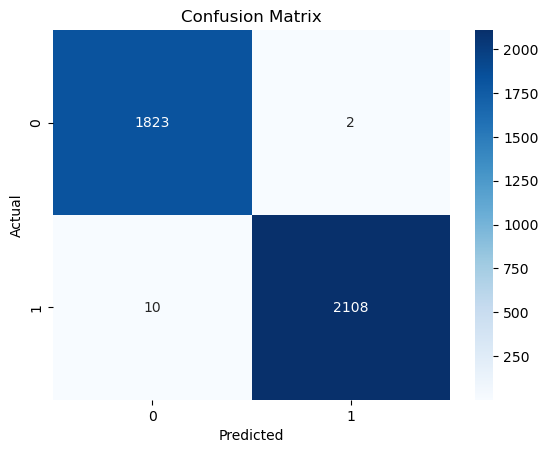

In [299]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

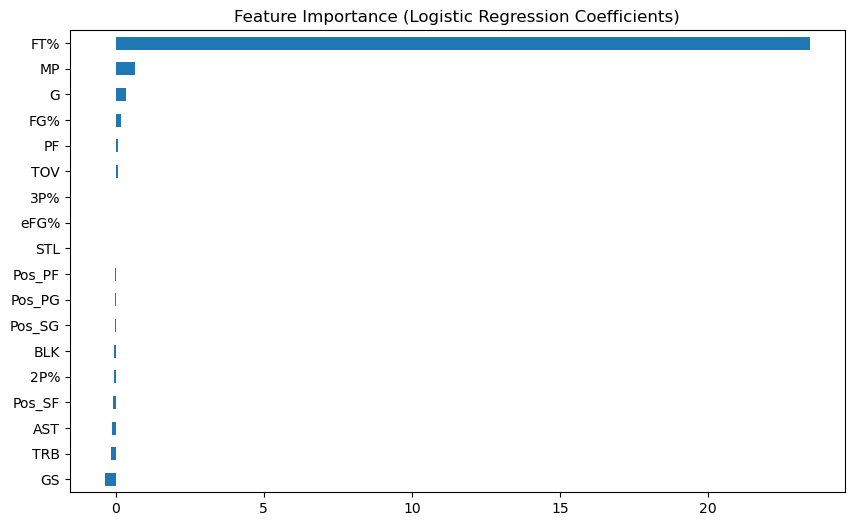

In [300]:
coefficients = pd.Series(model.coef_[0], index=X.columns)

coefficients.sort_values().plot(kind="barh", figsize=(10,6))
plt.title("Feature Importance (Logistic Regression Coefficients)")
plt.show()